## 1. Importy i konfiguracja

In [5]:
import sys
from pathlib import Path

import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dataset_generation.generate_squares import (
    warp_board,          
    extract_squares,    
    detect_board,
    PIECE_CLASSES,      
)

I0000 00:00:1781712640.620304   11282 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781712640.675276   11282 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781712641.907537   11282 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Konfiguracja ścieżek i parametrów

In [6]:
MODEL_PATH      = Path("piece_recognition/models/mlp.keras")  
IMAGE_PATH      = Path("dataset/chessred2k/images/99/G099_IMG093.jpg")     # przykładowy obraz do analizy
OUTPUT_DIR      = Path("results")

PADDING           = 4      
SQUARE_RESIZE     = 16     
ORIENTATION_FLIP  = False  

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Wczytanie modelu Keras

In [7]:
def load_keras_model(model_path: Path) -> keras.Model:
    """Wczytaj model z pliku .keras i wypisz podsumowanie."""
    model = keras.models.load_model(str(model_path))
    print(f"Model wczytany: {model_path.name}")
    print(f"Wejście: {model.input_shape}  |  Wyjście: {model.output_shape}")
    return model

model = load_keras_model(MODEL_PATH)

E0000 00:00:1781712643.427522   11282 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model wczytany: mlp.keras
Wejście: (None, 256)  |  Wyjście: (None, 13)


## 4. Przygotowanie cech pola szachownicy

In [8]:
def square_to_feature(square_bgr: np.ndarray,
                       size: int = SQUARE_RESIZE) -> np.ndarray:
    """
    Przekształć obraz pola w wektor cech (size*size,) float32 [0,1].
    MLP działa najlepiej na obrazach 16×16 px (spłaszczonych).
    """
    gray = cv2.cvtColor(square_bgr, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (size, size), interpolation=cv2.INTER_AREA)
    return resized.flatten().astype(np.float32) / 255.0


def board_to_feature_matrix(board_bgr: np.ndarray,
                              padding: int = PADDING,
                              size: int = SQUARE_RESIZE) -> np.ndarray:
    """
    Użyj extract_squares() z generate_squares.py,
    zwróć macierz (64, size*size) float32.
    """
    rows = []
    for _col, _row, sq in extract_squares(board_bgr, padding=padding):
        rows.append(square_to_feature(sq, size=size))
    return np.vstack(rows)   # (64, 256)


In [9]:
def classify_board(model: keras.Model,
                    feature_matrix: np.ndarray) -> list[str]:
    """
    Klasyfikuj 64 pola jednocześnie.
    Zwraca listę 64 nazw klas (w kolejności col-major, rząd 0 = ranga 8).
    """
    probs = model.predict(feature_matrix, verbose=0)  # (64, n_klas)
    indices = np.argmax(probs, axis=1)                # (64,)
    return [PIECE_CLASSES[i] for i in indices]


def build_piece_grid(classes_flat: list[str]) -> list[list[str]]:
    """
    Konwertuj płaską listę 64 klas (rząd=0 to ranga 8) na
    grid[rank_idx][file_idx], rank_idx 0 = ranga 1 (dół planszy).
    """
    grid = [["empty"] * 8 for _ in range(8)]
    idx = 0
    for row in range(8):       # row 0 → ranga 8
        for col in range(8):   # col 0 → plik a
            rank_idx = 7 - row
            grid[rank_idx][col] = classes_flat[idx]
            idx += 1
    return grid

## 6. Parser FEN

In [10]:
_FEN_SYMBOL = {
    "empty":         None,
    "white_pawn":    "P",  "white_knight": "N",  "white_bishop": "B",
    "white_rook":    "R",  "white_queen":  "Q",  "white_king":   "K",
    "black_pawn":    "p",  "black_knight": "n",  "black_bishop": "b",
    "black_rook":    "r",  "black_queen":  "q",  "black_king":   "k",
}

_SYMBOL_TO_CLASS = {v: k for k, v in _FEN_SYMBOL.items() if v is not None}



def grid_to_fen_position(grid: list[list[str]]) -> str:
    """
    Przekształć grid[rank_idx][file_idx] w string pozycji FEN.
    Rangi od 8 (góra) do 1 (dół), pliki od a do h.
    """
    ranks = []
    for rank_idx in range(7, -1, -1):   # ranga 8 → 1
        empty_run = 0
        rank_chars = []
        for file_idx in range(8):       # plik a → h
            sym = _FEN_SYMBOL.get(grid[rank_idx][file_idx])
            if sym is None:             # puste pole
                empty_run += 1
            else:
                if empty_run:
                    rank_chars.append(str(empty_run))
                    empty_run = 0
                rank_chars.append(sym)
        if empty_run:
            rank_chars.append(str(empty_run))
        ranks.append("".join(rank_chars))
    return "/".join(ranks)


def make_full_fen(position: str,
                  active: str = "w",
                  castling: str = "KQkq",
                  en_passant: str = "-",
                  halfmove: int = 0,
                  fullmove: int = 1) -> str:
    """Połącz pozycję z metadanymi w pełny ciąg FEN."""
    return f"{position} {active} {castling} {en_passant} {halfmove} {fullmove}"



def fen_position_to_grid(fen_position: str) -> list[list[str]]:
    """
    Parsuj string pozycji FEN (pierwsza część, bez metadanych)
    i zwróć grid[rank_idx][file_idx].

    Przykład:
        fen = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR"
        grid = fen_position_to_grid(fen)
    """
    grid = [["empty"] * 8 for _ in range(8)]
    ranks_str = fen_position.split(" ")[0].split("/")

    if len(ranks_str) != 8:
        raise ValueError(f"FEN musi mieć 8 rang, znaleziono {len(ranks_str)}")

    for rank_offset, rank_str in enumerate(ranks_str):
        rank_idx = 7 - rank_offset   # FEN zaczyna od rangi 8
        file_idx = 0
        for ch in rank_str:
            if ch.isdigit():
                file_idx += int(ch)  # puste pola
            elif ch in _SYMBOL_TO_CLASS:
                grid[rank_idx][file_idx] = _SYMBOL_TO_CLASS[ch]
                file_idx += 1
            else:
                raise ValueError(f"Nieznany symbol FEN: '{ch}'")
        if file_idx != 8:
            raise ValueError(f"Ranga {rank_idx+1}: oczekiwano 8 pól, znaleziono {file_idx}")

    return grid

## 7. Wizualizacja szachownicy

In [11]:
_UNICODE = {
    "white_king": "♔", "white_queen": "♕", "white_rook": "♖",
    "white_bishop": "♗", "white_knight": "♘", "white_pawn": "♙",
    "black_king": "♚", "black_queen": "♛", "black_rook": "♜",
    "black_bishop": "♝", "black_knight": "♞", "black_pawn": "♟",
    "empty": "",
}


def plot_board(grid: list[list[str]],
               title: str = "Szachownica",
               fen: str | None = None) -> None:
    """Narysuj szachownicę matplotlib z symbolami Unicode figur."""
    fig, ax = plt.subplots(figsize=(6, 6))
    light = "#F0D9B5"
    dark  = "#B58863"

    for rank_idx in range(8):
        for file_idx in range(8):
            color = light if (rank_idx + file_idx) % 2 == 0 else dark
            rect = mpatches.FancyBboxPatch(
                (file_idx, rank_idx), 1, 1,
                boxstyle="square,pad=0",
                facecolor=color, edgecolor="none"
            )
            ax.add_patch(rect)

            piece = grid[rank_idx][file_idx]
            sym = _UNICODE.get(piece, "")
            if sym:
                is_white = piece.startswith("white")
                ax.text(
                    file_idx + 0.5, rank_idx + 0.5, sym,
                    ha="center", va="center",
                    fontsize=26,
                    color="white" if is_white else "#1a1a1a",
                    fontweight="bold",
                )

    # Etykiety plików i rang
    for i, ch in enumerate("abcdefgh"):
        ax.text(i + 0.5, -0.35, ch, ha="center", va="center",
                fontsize=10, color="#444")
    for i in range(8):
        ax.text(-0.35, i + 0.5, str(i + 1), ha="center", va="center",
                fontsize=10, color="#444")

    ax.set_xlim(-0.5, 8.5)
    ax.set_ylim(-0.5, 8.5)
    ax.set_aspect("equal")
    ax.axis("off")

    subtitle = f"\nFEN: {fen}" if fen else ""
    ax.set_title(title + subtitle, fontsize=9, pad=8)
    plt.tight_layout()
    plt.show()

## 8. Pipeline

Obraz: G099_IMG093.jpg  3024×3024 px
Macierz cech: (64, 256)

FEN pozycji : 8/1K4K1/6K1/K2k4/2k1KK1P/8/6P1/8
Pełny FEN   : 8/1K4K1/6K1/K2k4/2k1KK1P/8/6P1/8 w KQkq - 0 1


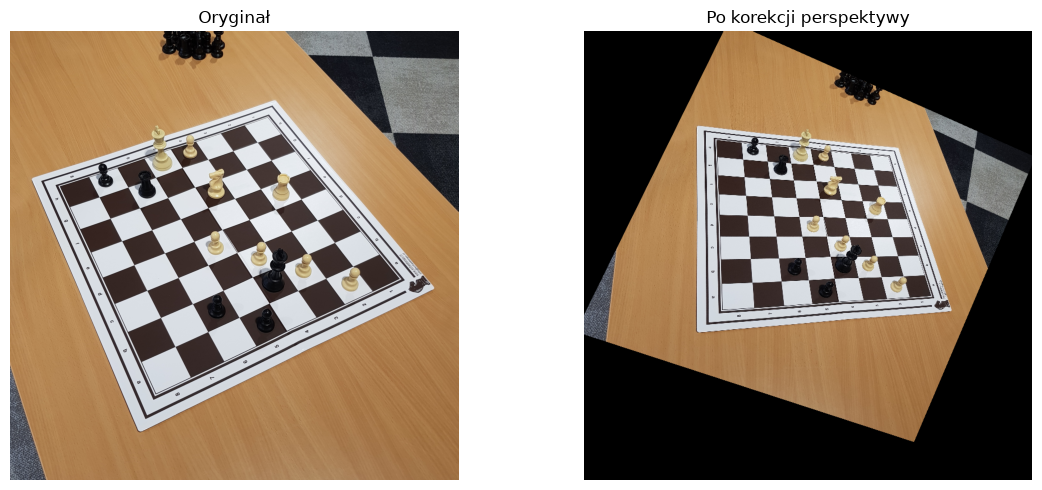

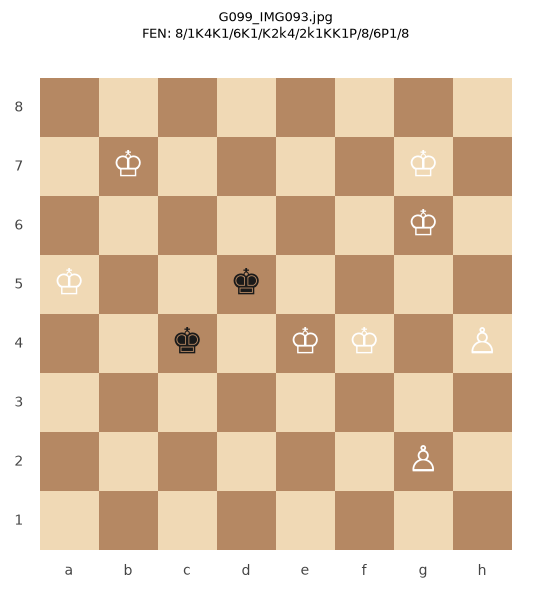

In [12]:
def analyze_single_image(
    image_path: Path,
    model: keras.Model,
    corners_json: Path | None = None,
    padding: int = PADDING,
    orientation_flip: bool = ORIENTATION_FLIP,
    visualize: bool = True,
) -> dict:
    """
    Pełny pipeline dla jednego obrazu.
    Korzysta z load_corners() i warp_board() z generate_squares.py.

    Zwraca dict z kluczami: grid, fen_position, fen_full, board_bgr.
    """
    # 1. Wczytanie obrazu
    img = cv2.imread(str(image_path))
    assert img is not None, f"Nie można wczytać: {image_path}"
    print(f"Obraz: {image_path.name}  {img.shape[1]}×{img.shape[0]} px")

    det = detect_board(img)
    if det is None:
        raise RuntimeError(f"Nie udało się wykryć szachownicy w: {image_path.name}")

    corners = det.corners
    board_bgr = warp_board(img, corners, orientation_flip=orientation_flip)
    feature_matrix = board_to_feature_matrix(board_bgr, padding=padding)
    print(f"Macierz cech: {feature_matrix.shape}")

    classes_flat = classify_board(model, feature_matrix)
    grid = build_piece_grid(classes_flat)
    fen_pos = grid_to_fen_position(grid)
    fen = make_full_fen(fen_pos)

    print(f"\nFEN pozycji : {fen_pos}")
    print(f"Pełny FEN   : {fen}")

    if visualize:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Oryginał")
        axes[0].axis("off")
        axes[1].imshow(cv2.cvtColor(board_bgr, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Po korekcji perspektywy")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

        plot_board(grid, title=image_path.name, fen=fen_pos)

    return {"grid": grid, "fen_position": fen_pos, "fen_full": fen, "board_bgr": board_bgr}


result = analyze_single_image(
    image_path=IMAGE_PATH,
    model=model
)